In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import tqdm

list(tqdm.tqdm(range(6,10)))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 33026.02it/s]


[2, 3]

In [3]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()

number_of_files = 5
event_type = 'ttbar_pu0'
# Load particles
particles_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_particles/train-{i:05d}-of-00100.parquet"
    with fs.open(file_path, "rb") as f:
        particles_list.append(pl.read_parquet(f))
particles = pl.concat(particles_list)

# Load calo_hits
calo_hits_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_calo_hits/train-{i:05d}-of-00100.parquet"
    with fs.open(file_path, "rb") as f:
        calo_hits_list.append(pl.read_parquet(f))
calo_hits = pl.concat(calo_hits_list)

# Load tracks
tracks_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_tracks/train-{i:05d}-of-00100.parquet"
    with fs.open(file_path, "rb") as f:
        tracks_list.append(pl.read_parquet(f))
tracks = pl.concat(tracks_list)

In [5]:
particles

event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary
u32,list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool]
0,"[76, 77, … 2033]","[213, -211, … 11]","[0.738762, 0.13957, … 0.000511]","[2491.611816, 489.566223, … 0.001127]","[1.0, -1.0, … -1.0]","[0.009162, 0.009162, … 246.824448]","[-0.003694, -0.003694, … 958.047424]","[196.070236, 196.070236, … 1920.47644]","[0.442453, 0.442453, … 7.283049]","[0.033283, -0.342658, … 0.000469]","[-0.117263, 0.317618, … 0.000247]","[2491.611816, 489.565979, … 0.000853]","[NaN, NaN, … NaN]","[NaN, NaN, … NaN]","[1, 1, … 1]","[9, 9, … 2019]","[true, true, … false]"
1,"[10, 11, … 2879]","[211, -211, … 22]","[0.13957, 0.13957, … 0.0]","[1935.443848, 28.814047, … 219.003906]","[1.0, -1.0, … 0.0]","[-0.023709, -0.023709, … -0.023674]","[0.010315, 0.010315, … 0.0104]","[106.12365, 106.12365, … 106.093628]","[0.150796, 0.150796, … 0.150897]","[-0.005252, 0.212135, … 0.319321]","[0.20687, -0.101696, … 0.635319]","[1935.443848, 28.81275, … -219.002762]","[NaN, NaN, … 0.0]","[NaN, NaN, … 0.0]","[1, 1, … 1]","[3, 3, … 80]","[true, true, … false]"
2,"[64, 65, … 3238]","[-523, 111, … 11]","[5.3252, 0.13498, … 0.000511]","[18.453094, 3.594066, … 0.000571]","[0.0, 0.0, … -1.0]","[-0.013339, -0.013339, … -570.805908]","[-0.005375, -0.005375, … -7.775224]","[49.383862, 49.383862, … -1297.380615]","[0.034972, 0.034972, … 17.113577]","[17.1297, 3.394495, … 0.000148]","[-2.952355, -0.652638, … -0.000167]","[3.164794, 0.974962, … 0.000124]","[-0.007563, -0.007797, … NaN]","[49.386089, 49.387272, … NaN]","[1, 1, … 1]","[9, 9, … 3236]","[true, true, … false]"
3,"[43, 44, … 4223]","[2212, 221, … 22]","[0.93827, 0.54785, … 0.0]","[22.615156, 25.405207, … 1.411551]","[1.0, 0.0, … 0.0]","[0.008929, 0.008929, … 0.008918]","[-0.012789, -0.012789, … -0.012747]","[61.058159, 61.058159, … 61.060375]","[-0.078921, -0.078921, … -0.078914]","[0.010547, -0.045738, … 0.0583]","[0.230913, 0.842978, … 0.008144]","[22.594501, 25.385263, … 1.410324]","[-0.009503, -0.008223, … -0.013858]","[62.267075, 61.456688, … 60.89101]","[1, 1, … 1]","[8, 8, … 136]","[true, true, … false]"
4,"[113, 114, … 2391]","[223, 211, … 11]","[0.780666, 0.13957, … 0.000511]","[144.329086, 1.095027, … 0.155885]","[0.0, 1.0, … -1.0]","[0.006297, 0.006297, … 1013.232483]","[0.01418, 0.01418, … -1325.503418]","[52.569878, 52.569878, … 1553.529907]","[-0.277733, -0.277733, … 7.379701]","[-0.278494, 0.021264, … 0.136147]","[0.013545, 0.021074, … -0.059275]","[144.326706, 1.085683, … 0.047438]","[0.0, 0.005636, … NaN]","[0.0, 52.045685, … NaN]","[1, 1, … 1]","[8, 8, … 2385]","[true, true, … false]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
4995,"[175, 176, … 7304]","[2214, -2214, … 11]","[1.181227, 1.138318, … 0.000511]","[52.576977, 10.516143, … 0.414192]","[1.0, -1.0, … -1.0]","[0.001353, 0.001353, … -580.710327]","[0.011452, 0.011452, … -2386.250732]","[-50.412865, -50.412865, … -1222.076782]","[-0.151203, -0.151203, … 8.926961]","[0.561186, 0.019391, … -0.081602]","[-0.094309, 0.308637, … -0.35799]","[52.560627, 10.449778, … -0.191674]","[0.011518, -0.000632, … NaN]","[-50.360783, -50.801952, … NaN]","[1, 1, … 1]","[9, 9, … 995]","[true, true, … false]"
4996,"[112, 113, … 5897]","[211, 331, … -11]","[0.13957, 0.95746, … 0.000511]","[10.392654, 23.669096, … 0.377869]","[1.0, 0.0, … 1.0]","[0.044075, 0.044075, … 899.391174]","[0.018182, 0.018182, … 1034.687134]","[-63.553421, -63.553421, … -521.611877]","[0.296537, 0.296537, … 5.136237]","[-0.494249, 0.127513, … 0.287742]","[0.480583, 0.819858, … 0.215606]","[10.368826, 23.635164, … -0.116206]","[-0.043762, -0.040757, … NaN]","[-63.268784, -64.258163, … NaN]","[1, 1, … 1]","[8, 8, … 1003]","[true, true, … false]"
4997,"[171, 172, … 9743]","[211, 223, … -11]","[0.13957, 0.801627, … 0.000511]","[50.049614, 229.350662, … 0.216116]","

In [ ]:
# Check if any particle has multiple tracks
particles_with_multiple_tracks = (
    tracks.lazy()
    .select(['event_id', 'majority_particle_id', 'track_id'])
    .explode(['majority_particle_id', 'track_id'])
    .group_by('majority_particle_id')
    .agg(pl.col('track_id').n_unique().alias('num_tracks'))
    .filter(pl.col('num_tracks') > 1)
    .collect()
)

if particles_with_multiple_tracks.height > 0:
    print(f"Found {particles_with_multiple_tracks.height} particles with multiple tracks.")
    print(particles_with_multiple_tracks.head())
else:
    print("No particles have multiple tracks.")

In [6]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv3
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)



Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 11 iterations on 20291528 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 8 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 16 iterations.
Step 4: Final validation...


event_id,is_target_particle,is_truth_particle,enter_calo,has_track,is_target_particle_right,enter_calo_right,has_track_right,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary,created_inside_calo,eta,phi,pt,is_parent_missing,created_inside_calo_right,eta_right,phi_right,pt_right
u32,list[bool],list[bool],list[bool],list[bool],list[bool],list[bool],list[bool],list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool],list[bool],list[f32],list[f32],list[f32],list[bool],list[bool],list[f32],list[f32],list[f32]
3842,"[false, false, … false]","[false, true, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[124, 125, … 2995]","[-311, 221, … 11]","[0.49761, 0.54785, … 0.000511]","[4.906617, 21.19256, … 0.114608]","[0.0, 0.0, … -1.0]","[-0.005685, -0.005685, … -345.464203]","[-0.005218, -0.005218, … -99.525673]","[-5.128552, -5.128552, … 4397.297852]","[0.03416, 0.03416, … 14.767958]","[0.08525, -1.408715, … -0.010342]","[-0.044127, -0.71016, … -0.002632]","[4.880375, 21.126657, … 0.114109]","[-0.007247, 0.0021, … NaN]","[-4.993791, -5.227993, … NaN]","[1, 1, … 1]","[9, 9, … 2988]","[true, true, … false]","[false, false, … true]","[4.621938, 3.289173, … 3.064899]","[-0.47764, -2.674655, … -2.892415]","[0.095994, 1.577595, … 0.010672]","[true, true, … false]","[false, false, … true]","[4.621938, 3.289173, … 3.064899]","[-0.47764, -2.674655, … -2.892415]","[0.095994, 1.577595, … 0.010672]"
564,"[false, false, … false]","[true, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[63, 64, … 3335]","[-311, 221, … 22]","[0.49761, 0.54785, … 0.0]","[51.337345, 13.599112, … 6.285358]","[0.0, 0.0, … 0.0]","[-0.005761, -0.005761, … -0.005803]","[0.004079, 0.004079, … 0.004121]","[74.737396, 74.737396, … 74.741653]","[-0.218221, -0.218221, … -0.218206]","[3.629128, 0.116675, … -0.094217]","[4.893797, 0.803616, … 0.108105]","[50.972103, 13.563786, … 6.283722]","[0.007058, 0.006288, … 0.001667]","[74.738693, 74.683792, … 74.438461]","[1, 1, … 1]","[9, 9, … 360]","[true, true, … false]","[false, false, … false]","[2.820903, 3.50965, … 4.47336]","[0.932708, 1.426616, … 2.28766]","[6.092603, 0.812042, … 0.1434]","[true, true, … false]","[false, false, … false]","[2.820903, 3.50965, … 4.47336]","[0.932708, 1.426616, … 2.28766]","[6.092603, 0.812042, … 0.1434]"
2785,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[37, 38, … 3512]","[111, 211, … 22]","[0.13498, 0.13957, … 0.0]","[91.035721, 21.470585, … 0.52735]","[0.0, 1.0, … 0.0]","[-0.014209, -0.014209, … -0.014122]","[0.011959, 0.011959, … 0.012019]","[54.471306, 54.471306, … 54.506817]","[0.111093, 0.111093, … 0.111211]","[0.081948, 0.457659, … -0.006046]","[-0.610498, 0.292149, … 0.003369]","[91.033531, 21.463266, … 0.527304]","[0.0, 0.017725, … -0.003625]","[0.0, 54.690388, … 53.121281]","[1, 1, … 1]","[8, 8, … 234]","[true, true, … false]","[false, false, … false]","[5.688938, 4.370375, … 5.026374]","[-1.437363, 0.568146, … 2.633205]","[0.615974, 0.542958, … 0.006921]","[true, true, … false]","[false, false, … false]","[5.688938, 4.370375, … 5.026374]","[-1.437363, 0.568146, … 2.633205]","[0.615974, 0.542958, … 0.006921]"
2002,"[false, false, … false]","[true, true, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[92, 93, … 6735]","[-511, 221, … -11]","[5.27958, 0.54785, … 0.000511]","[99.230431, 4.393559, … 0.11412]","[0.0, 0.0, … 1.0]","[-0.004815, -0.004815, … 1257.155029]","[0.021032, 0.021032, … -363.813629]"

In [ ]:
particles = set_target_particles_maskv3(particles)
particles

In [7]:
particles['is_truth_particle']

is_truth_particle
list[bool]
"[false, true, … false]"
"[true, false, … false]"
"[false, false, … false]"
"[true, true, … false]"
"[false, true, … false]"
…
"[true, true, … false]"
"[false, true, … false]"
"[false, false, … false]"


In [11]:
from primary.preprocessing import backtrack_to_target
target_p = (
    particles.lazy()
    .select(['event_id', 'particle_id', 'is_target_particle'])
    .explode( 'particle_id','is_target_particle')
    .filter(pl.col('is_target_particle') )
    .select(['event_id', 'particle_id'])
)
truth_p = (
    particles.lazy()
    .select(['event_id', 'particle_id', 'is_truth_particle'])
    .explode('particle_id','is_truth_particle')
    .filter(pl.col('is_truth_particle') )
    .select(['event_id', 'particle_id'])
)
mappings = backtrack_to_target(particles=particles, src_df=target_p, target_df=truth_p).rename({'src_particle_id':'target_particle_id','target_particle_id':'truth_particle_id'})

Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


In [ ]:
# apply to truth 1 Gev

# accept target if parent parent pt > 1 GeV and target pt > 0.3

In [12]:
combined = (
    particles.lazy()
    .select(['event_id', 'particle_id', 'pt', 'eta', 'energy'])
    .explode(['particle_id', 'pt', 'eta', 'energy']) 
    .join(mappings.lazy(),
           left_on=['event_id', 'particle_id'],
              right_on=['event_id', 'target_particle_id']
           , how='inner')
    .group_by(['event_id', 'truth_particle_id'])
    .agg([pl.col('pt').sum().alias('total_target_pt'),
          pl.col('energy').sum().alias('total_target_energy')])
    .join(
        particles.lazy()
        .select(['event_id', 'particle_id', 'pt', 'eta', 'pdg_id', 'energy'])
        .explode(['particle_id', 'pt', 'eta', 'pdg_id', 'energy']) 
        .rename({'pt':'truth_pt', 'particle_id':'truth_particle_id'}),
        on=['event_id', 'truth_particle_id'],
        how='inner'
    )
    .with_columns([
        (pl.col('truth_pt') - pl.col('total_target_pt')).alias('pt_diff'),
        (pl.col('total_target_pt') / pl.col('truth_pt')).alias('pt_ratio')])).collect()

SyntaxError: '(' was never closed (2785085322.py, line 32)

In [7]:
combined.filter(
    (pl.col('truth_pt') > 200) & (pl.col('total_target_pt') > 100)
    & (pl.col('pt_ratio') <0.5)
    #& (pl.col('event_id')==4466) & (pl.col('truth_particle_id')==424)
      )

event_id,truth_particle_id,total_target_pt,total_target_energy,truth_pt,eta,pdg_id,energy,pt_diff,pt_ratio
u32,i64,f32,f32,f32,f32,i64,f32,f32,f32
4005,917,102.670029,122.494629,209.069626,-0.613099,-15,249.615875,106.399597,0.491081
3082,695,100.678818,225.985046,263.693451,1.441226,511,588.390991,163.014633,0.381802
542,687,113.450775,126.118607,237.978256,-0.464764,523,264.200195,124.527481,0.476727


In [10]:
from primary.interactive_plot import plot_3d_particle_hierarchy
plot_3d_particle_hierarchy(particles, calo_hits=calo_hits, event_id=5423)


KeyboardInterrupt



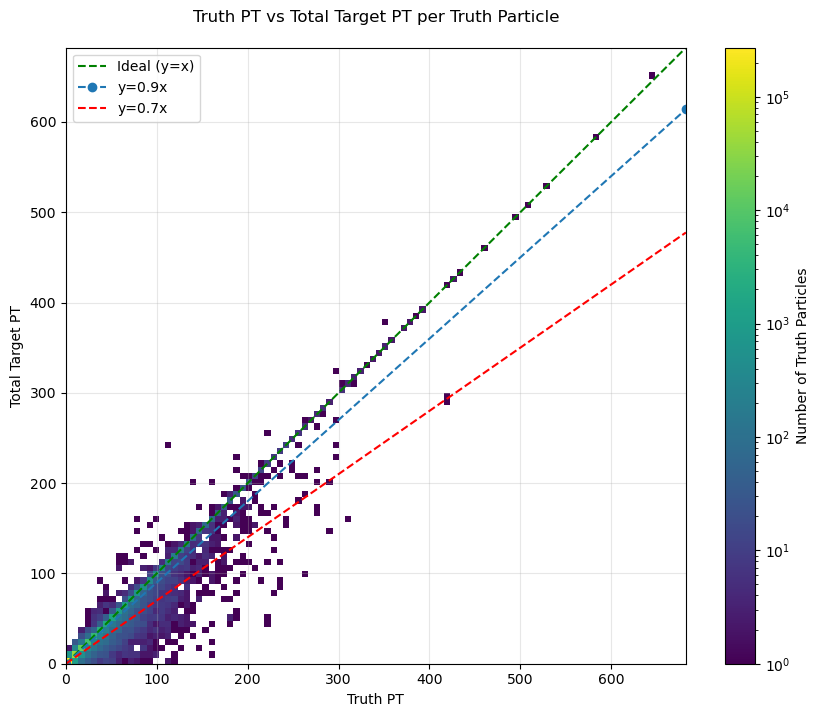

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import polars as pl
# --- 2. Plotting ---
x = combined['truth_pt'].to_numpy()
y = combined['total_target_pt'].to_numpy()

# Determine plot limits based on data max
max_val = max(np.max(x), np.max(y)) * 1.05

plt.figure(figsize=(10, 8))

# 2D Histogram
h = plt.hist2d(x, y, bins=100, range=[[0, max_val], [0, max_val]], 
                cmap='viridis', norm=LogNorm(), cmin=1)

# Add colorbar
cbar = plt.colorbar(h[3])
cbar.set_label('Number of Truth Particles')

# Add diagonal reference line (Ideal y=x)
plt.plot([0, max_val], [0, max_val], 'g--', linewidth=1.5, label='Ideal (y=x)')

# Add orange line for y=0.9x
plt.plot([0, max_val], [0, 0.9 * max_val], 'o--', linewidth=1.5, label='y=0.9x')

# Add red line for y=0.7x
plt.plot([0, max_val], [0, 0.7 * max_val], 'r--', linewidth=1.5, label='y=0.7x')

# Labels and Title
plt.xlabel("Truth PT")
plt.ylabel("Total Target PT")
plt.title(f"Truth PT vs Total Target PT per Truth Particle\n")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [23]:
from primary.interactive_plot import target_vs_truth_particles
target_vs_truth_particles(particles)

Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


    'data': [{'customdata': array([[-1.50000000e+01,  5.51627930e+04],
         …

event_id,energy_target,energy_truth
u32,f32,f32
4768,1060.661621,1093.598389
2803,864.63446,882.952881
2617,499.449585,526.621643
2427,386.633972,419.887695
3126,1617.69751,1639.721191
…,…,…
1247,1315.542725,1406.748291
1609,622.359741,654.849426
4232,1149.467163,1209.431396


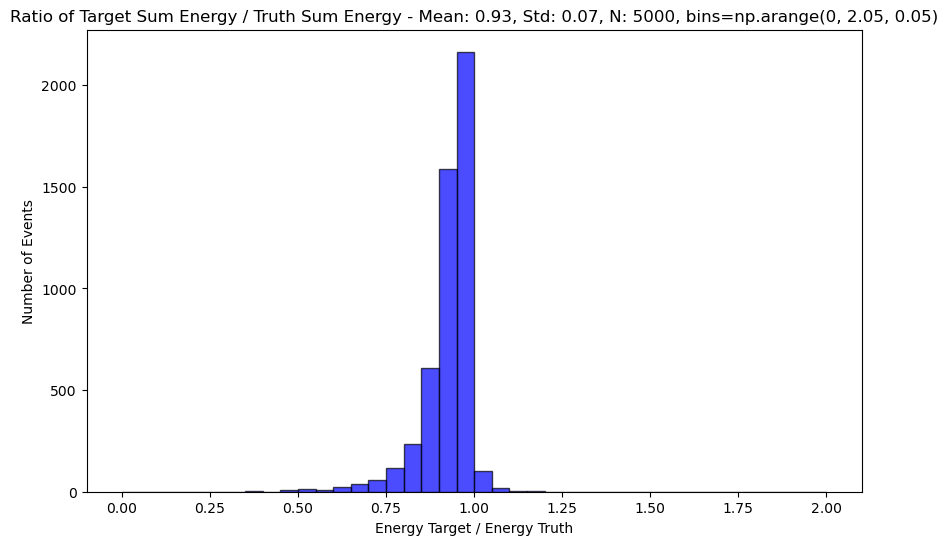

In [24]:
from primary.plot import histogram_ht_ratio,hist2d_ht_truth_vs_target, histogram_energy_ratio
histogram_energy_ratio(particles)

event_id,ht_target,ht_truth
u32,f32,f32
7652,298.776062,325.012512
3335,720.725952,759.783142
5702,288.584106,309.895966
6101,281.539429,317.964844
3213,300.473938,345.605408
…,…,…
1487,617.413513,706.24054
9162,496.370789,599.754944
7919,536.898743,611.494629


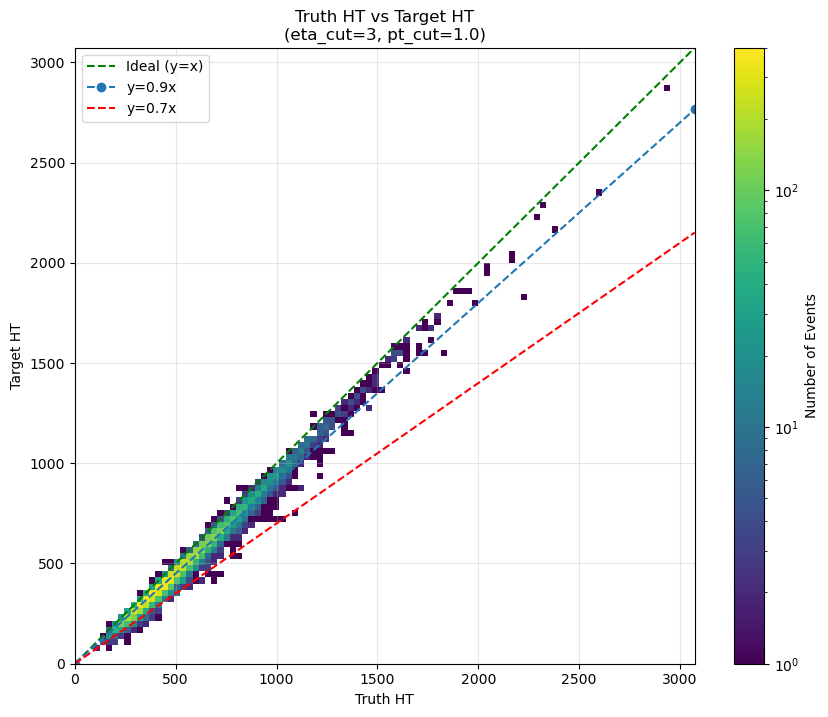

In [17]:
hist2d_ht_truth_vs_target(particles,eta_cut=3, pt_cut=1.0)

In [28]:
# calo clusters cutoff plots
from primary.plot import plot_calo_cluster_cutoff_plots
from primary.preprocessing import add_ms_cluster_labels
calo_hits = add_ms_cluster_labels(calo_hits, bandwidth=120.0)


--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 4000 events. Time: 2.59s
Workload optimized: 4000 events merged into 4000 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 1045.54s


In [6]:
from primary.create_trainning_dataset import preprocess_for_model
preprocessed = preprocess_for_model(particles=particles, tracks=tracks, calo_hits=calo_hits, num_of_events=1000, pt_cut=1, eta_cut=3.0, clusters_cutoff=0.25)

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4099408 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 3 iterations.
Step 4: Final validation...
--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 1000 events. Time: 0.68s
Workload optimized: 1000 events merged into 1000 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 261.67s
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 15 iterations.
Step 4: Final validation...
--- Orphan Filtering Stats ---
Total target particles before: 96084
Total target particles after:  9

In [7]:
df_deps=preprocessed['target_particles_deps']
df_particles=preprocessed['target_particles']
df_clusters=preprocessed['calo_clusters']
df_tracks=preprocessed['tracks']

In [8]:
df_clusters

event_id,cluster_id,total_cluster_energy,hcal_energy,sigma_eta,sigma_phi,sigma_rho,cluster_phi,cluster_eta,cluster_rho,hcal_fraction
u32,list[i32],list[f64],list[f64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f64]
0,"[0, 1, … 291]","[117.038543, 13.86953, … 0.58137]","[0.0, 0.0, … 0.58137]","[0.01673, 0.036442, … 0.05332]","[0.022366, 0.028642, … 0.176542]","[27.062729, 55.675186, … 14.357333]","[-1.505896, 0.874787, … -1.406761]","[1.687719, -0.214194, … 3.168979]","[1265.896118, 1344.90979, … 367.421204]","[0.0, 0.0, … 1.0]"
1,"[0, 1, … 368]","[127.071303, 65.037671, … 0.811319]","[0.0, 0.0, … 0.0]","[0.016922, 0.042009, … 0.0]","[0.021009, 0.060175, … 0.0]","[34.49913, 40.156582, … 0.0]","[-1.781798, -1.043302, … 1.841474]","[-1.10054, -2.008766, … -1.231915]","[1332.636353, 900.028076, … 1424.592529]","[0.0, 0.0, … 0.0]"
2,"[0, 1, … 576]","[59.975367, 47.772519, … 0.819313]","[0.0, 0.0, … 0.819313]","[0.024936, 0.032155, … 0.0]","[0.40881, 0.038473, … 0.0]","[43.255806, 44.214653, … 0.0]","[3.057412, -2.035884, … -2.068882]","[0.244793, -1.473731, … -1.248928]","[1334.866089, 1357.624756, … 2566.729736]","[0.0, 0.0, … 1.0]"
3,"[0, 1, … 700]","[48.13458, 45.11502, … 0.427596]","[0.0, 0.0, … 0.427596]","[0.039802, 0.027216, … 0.018499]","[0.047512, 0.052917, … 0.030104]","[59.174438, 43.704994, … 63.050285]","[2.182628, -0.409989, … -2.668055]","[0.307553, -0.241523, … 0.991946]","[1366.6521, 1342.675171, … 1857.566162]","[0.0, 0.0, … 1.0]"
4,"[0, 1, … 482]","[46.673636, 14.84895, … 1.176899]","[0.0, 0.0, … 1.176899]","[0.021042, 0.021785, … 0.0]","[0.044711, 0.022532, … 0.0]","[55.661095, 50.291481, … 0.0]","[-0.575668, 1.02751, … 3.058474]","[0.755694, 0.559448, … 0.099463]","[1341.952271, 1368.279297, … 1806.737427]","[0.0, 0.0, … 1.0]"
…,…,…,…,…,…,…,…,…,…,…
995,"[0, 1, … 909]","[178.899145, 53.078415, … 0.311949]","[0.0, 0.0, … 0.311949]","[0.043587, 0.036794, … 0.022058]","[0.050596, 0.041631, … 0.03268]","[63.85331, 50.812042, … 68.766045]","[-0.340856, 2.486166, … -2.823586]","[0.673893, -0.602709, … 0.059663]","[1402.301025, 1356.122559, … 2010.104614]","[0.0, 0.0, … 1.0]"
996,"[0, 1, … 949]","[160.598688, 105.315553, … 0.838095]","[0.0, 0.0, … 0.838095]","[0.07089, 0.038415, … 0.0]","[0.147197, 0.055058, … 0.0]","[27.07921, 38.834797, … 0.0]","[0.843383, 1.620259, … 2.954425]","[-2.875715, -1.918133, … -1.564991]","[377.04306, 990.042542, … 1773.46228]","[0.0, 0.0, … 1.0]"
997,"[0, 1, … 988]","[818.562793, 42.76936, … 0.348223]","[0.0, 0.0, … 0.348223]","[0.056181, 0.12039, … 0.033317]","[0.061527, 0.054964, … 0.014744]","[37.325344, 82.404259, … 71.48912]","[-1.99094, 1.939214, … -2.833102]","[2.38528, 2.347461, … -1.350298]","[621.861267, 643.106812, … 2140.07251]","[0.0, 0.0, … 1.0]"


In [9]:
# ...existing code...
# 1. Flatten particles and create a local index (0 to N-1) to match df_deps format
flat_particles = (
    df_particles.lazy()
    .select(["event_id", "particle_id", "pdg_id", "has_track", "energy", "pt"])
    .with_columns(
        particle_idx=pl.int_ranges(0, pl.col("particle_id").list.len())
    )
    .explode(["particle_id", "pdg_id", "has_track", "energy", "pt", "particle_idx"])
)

# 2. Get the set of particle indices that HAVE energy deposits
particles_with_deps = (
    df_deps.lazy()
    .select(["event_id", "particle_idx"])
    .explode("particle_idx")
    .unique()
    .with_columns(has_deps=pl.lit(True))
)

# 3. Join and find the "Ghosts" (No Track AND No Deps)
ghost_particles = (
    flat_particles.join(
        particles_with_deps, on=["event_id", "particle_idx"], how="left"
    )
    .with_columns(pl.col("has_deps").fill_null(False))
    .filter((~pl.col("has_track")) & (~pl.col("has_deps")))
    .collect()
)

# 4. Report results
num_ghosts = ghost_particles.height
print(f"Found {num_ghosts} particles with NO track and NO energy deposits.")

if num_ghosts > 0:
    print("\nSample of Ghost Particles:")
    print(ghost_particles.sort('pt', descending=True).head(10))

    print("\nBreakdown by PDG ID (Likely Neutrinos?):")
    print(
        ghost_particles.group_by("pdg_id")
        .agg(pl.count("event_id").alias("count")))
        # filepath: /storage/agrp/barakma/PileupODD/run_preprocessing.ipynb
# ...existing code...
# 4. Report results
num_ghosts = ghost_particles.height
print(f"Found {num_ghosts} particles with NO track and NO energy deposits.")

if num_ghosts > 0:
    print("\nSample of Ghost Particles:")
    print(ghost_particles.head(10))

    print("\nBreakdown by PDG ID (Likely Neutrinos?):")
    print(
        ghost_particles.group_by("pdg_id")
        .agg(pl.count("event_id").alias("count"))
        .sort("count", descending=True)
    )

Found 0 particles with NO track and NO energy deposits.
Found 0 particles with NO track and NO energy deposits.


In [19]:
particles.select('pdg_id').explode("pdg_id").filter(pl.col('pdg_id')==-999).count()

pdg_id
u32
0


In [10]:
# Verify that all particle_idx in deps refer to valid particles
# Join deps with particles to compare max index with length
invalid_indices = (
    df_tracks.lazy()
    .select(["event_id", "particle_idx"])
    .join(
        df_particles.lazy().select(
            pl.col("event_id"), 
            pl.col("particle_id").list.len().alias("num_particles")
        ),
        on="event_id"
    )
    .with_columns(
        pl.col("particle_idx").list.max().alias("max_referenced_idx")
    )
    .filter(
        pl.col("max_referenced_idx") >= pl.col("num_particles")
    )
    .collect()
)

if invalid_indices.height == 0:
    print("✅ All particle indices in deps are valid!")
else:
    print(f"❌ Found {invalid_indices.height} events with invalid indices:")
    print(invalid_indices)

✅ All particle indices in deps are valid!


In [11]:
def check_list_lengths(df, name):
    print(f"Checking {name}...")
    # Get columns that are of List type
    list_cols = [col for col, dtype in df.schema.items() if isinstance(dtype, pl.List)]
    
    if not list_cols:
        print(f"  No list columns found in {name}")
        return

    # Create expressions to get length of each list column
    length_exprs = [pl.col(c).list.len().alias(f"{c}_len") for c in list_cols]
    
    # Check if all lengths are equal 
    validity_check = df.lazy().select(
        pl.col("event_id"),
        (pl.min_horizontal(length_exprs) == pl.max_horizontal(length_exprs)).alias("is_consistent")
    ).filter(~pl.col("is_consistent")).collect()
    
    if validity_check.height == 0:
        print(f"  ✅ All list columns in {name} have consistent lengths per event.")
    else:
        print(f"  ❌ Found {validity_check.height} inconsistent events in {name}!")
        print(validity_check.head())
        # To debug which columns mismatch, we can print the lengths for the bad rows
        bad_ids = validity_check["event_id"]
        print("  Bad row lengths details:")
        print(df.filter(pl.col("event_id").is_in(bad_ids)).select(["event_id"] + length_exprs).head())

# Run checks
dfs_to_check = {
    "target_particles": df_particles,
    "calo_clusters": df_clusters,
    "tracks": df_tracks,
    "target_particles_deps": df_deps
}

for name, df in dfs_to_check.items():
    check_list_lengths(df, name)

Checking target_particles...
  ✅ All list columns in target_particles have consistent lengths per event.
Checking calo_clusters...
  ✅ All list columns in calo_clusters have consistent lengths per event.
Checking tracks...
  ✅ All list columns in tracks have consistent lengths per event.
Checking target_particles_deps...
  ✅ All list columns in target_particles_deps have consistent lengths per event.


In [23]:
df_clusters

event_id,cluster_id,total_cluster_energy,hcal_energy,sigma_eta,sigma_phi,sigma_rho,cluster_phi,cluster_eta,cluster_rho,hcal_fraction
u32,list[i32],list[f64],list[f64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f64]
0,"[0, 1, … 291]","[117.038543, 13.86953, … 0.58137]","[0.0, 0.0, … 0.58137]","[0.01673, 0.036442, … 0.05332]","[0.022366, 0.028642, … 0.176542]","[27.062729, 55.675186, … 14.357333]","[-1.505896, 0.874787, … -1.406761]","[1.687719, -0.214194, … 3.168979]","[1265.896118, 1344.90979, … 367.421204]","[0.0, 0.0, … 1.0]"
1,"[0, 1, … 368]","[127.071303, 65.037671, … 0.811319]","[0.0, 0.0, … 0.0]","[0.016922, 0.042009, … 0.0]","[0.021009, 0.060175, … 0.0]","[34.49913, 40.156582, … 0.0]","[-1.781798, -1.043302, … 1.841474]","[-1.10054, -2.008766, … -1.231915]","[1332.636353, 900.028076, … 1424.592529]","[0.0, 0.0, … 0.0]"
2,"[0, 1, … 576]","[59.975367, 47.772519, … 0.819313]","[0.0, 0.0, … 0.819313]","[0.024936, 0.032155, … 0.0]","[0.40881, 0.038473, … 0.0]","[43.255806, 44.214653, … 0.0]","[3.057412, -2.035884, … -2.068882]","[0.244793, -1.473731, … -1.248928]","[1334.866089, 1357.624756, … 2566.729736]","[0.0, 0.0, … 1.0]"
3,"[0, 1, … 700]","[48.13458, 45.11502, … 0.427596]","[0.0, 0.0, … 0.427596]","[0.039802, 0.027216, … 0.018499]","[0.047512, 0.052917, … 0.030104]","[59.174438, 43.704994, … 63.050285]","[2.182628, -0.409989, … -2.668055]","[0.307553, -0.241523, … 0.991946]","[1366.6521, 1342.675171, … 1857.566162]","[0.0, 0.0, … 1.0]"
4,"[0, 1, … 482]","[46.673636, 14.84895, … 1.176899]","[0.0, 0.0, … 1.176899]","[0.021042, 0.021785, … 0.0]","[0.044711, 0.022532, … 0.0]","[55.661095, 50.291481, … 0.0]","[-0.575668, 1.02751, … 3.058474]","[0.755694, 0.559448, … 0.099463]","[1341.952271, 1368.279297, … 1806.737427]","[0.0, 0.0, … 1.0]"
…,…,…,…,…,…,…,…,…,…,…
995,"[0, 1, … 909]","[178.899145, 53.078415, … 0.311949]","[0.0, 0.0, … 0.311949]","[0.043587, 0.036794, … 0.022058]","[0.050596, 0.041631, … 0.03268]","[63.85331, 50.812042, … 68.766045]","[-0.340856, 2.486166, … -2.823586]","[0.673893, -0.602709, … 0.059663]","[1402.301025, 1356.122559, … 2010.104614]","[0.0, 0.0, … 1.0]"
996,"[0, 1, … 949]","[160.598688, 105.315553, … 0.838095]","[0.0, 0.0, … 0.838095]","[0.07089, 0.038415, … 0.0]","[0.147197, 0.055058, … 0.0]","[27.07921, 38.834797, … 0.0]","[0.843383, 1.620259, … 2.954425]","[-2.875715, -1.918133, … -1.564991]","[377.04306, 990.042542, … 1773.46228]","[0.0, 0.0, … 1.0]"
997,"[0, 1, … 988]","[818.562793, 42.76936, … 0.348223]","[0.0, 0.0, … 0.348223]","[0.056181, 0.12039, … 0.033317]","[0.061527, 0.054964, … 0.014744]","[37.325344, 82.404259, … 71.48912]","[-1.99094, 1.939214, … -2.833102]","[2.38528, 2.347461, … -1.350298]","[621.861267, 643.106812, … 2140.07251]","[0.0, 0.0, … 1.0]"


In [32]:
df_tracks[0].select(pl.col("particle_idx").explode()).to_series().to_torch()

tensor([ 5,  0,  1,  2, 17,  8, 14, 18, 13, 15, 20, 19, 16,  7,  4,  3,  6])

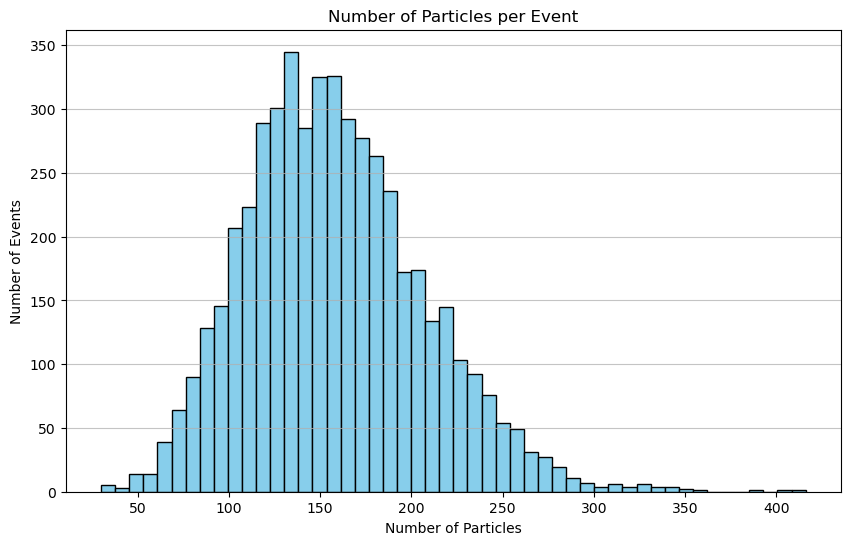

In [27]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = (
    particles.lazy()
    .select('event_id', 'particle_id', 'is_target_particle')
    .explode('particle_id', 'is_target_particle')
    .filter('is_target_particle')
    .group_by('event_id')
    .agg(pl.col('particle_id').count().alias('num_particles'))
    .collect()
)

plt.figure(figsize=(10, 6))
plt.hist(n_particles['num_particles'], bins=50, color='skyblue', edgecolor='black')
plt.title('Number of Particles per Event')
plt.xlabel('Number of Particles')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()

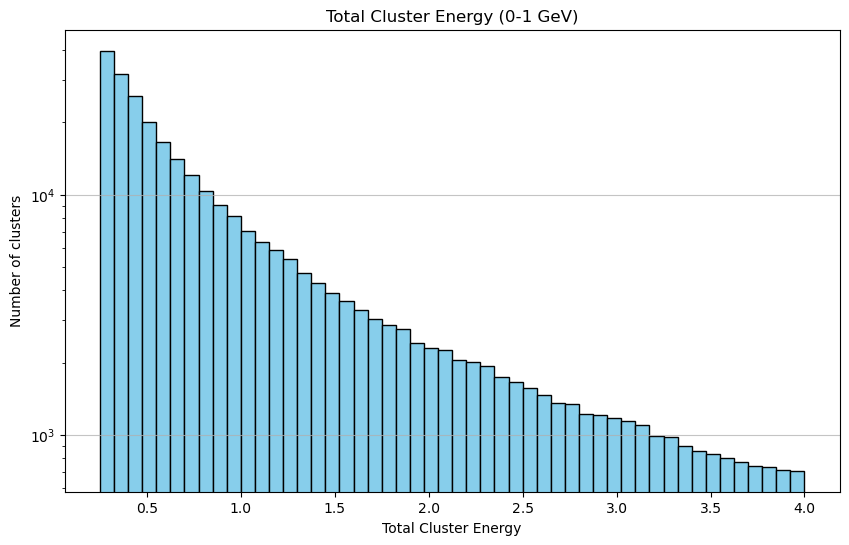

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate number of particles per event from target_particles
n_particles = df_clusters.select(pl.col("total_cluster_energy")).explode("total_cluster_energy").to_series().to_numpy()

# Filter to only show values between 0 and 1
n_particles_filtered = n_particles[(n_particles >= 0.001) & (n_particles <= 4)]

plt.figure(figsize=(10, 6))
plt.hist(n_particles_filtered, bins=50, color='skyblue', edgecolor='black')
plt.title('Total Cluster Energy (0-1 GeV)')
plt.xlabel('Total Cluster Energy')
plt.ylabel('Number of clusters')
plt.grid(axis='y', alpha=0.75)
# log scale for y-axis
plt.yscale('log')
plt.show()


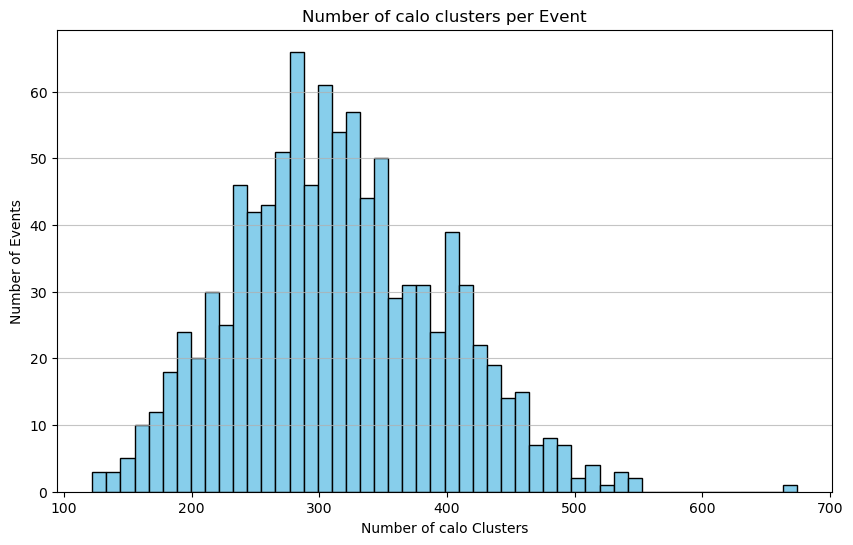

In [14]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = df_clusters["cluster_id"].list.len()

plt.figure(figsize=(10, 6))
plt.hist(n_particles, bins=50, color='skyblue', edgecolor='black')
plt.title('Number of calo clusters per Event')
plt.xlabel('Number of calo Clusters')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()

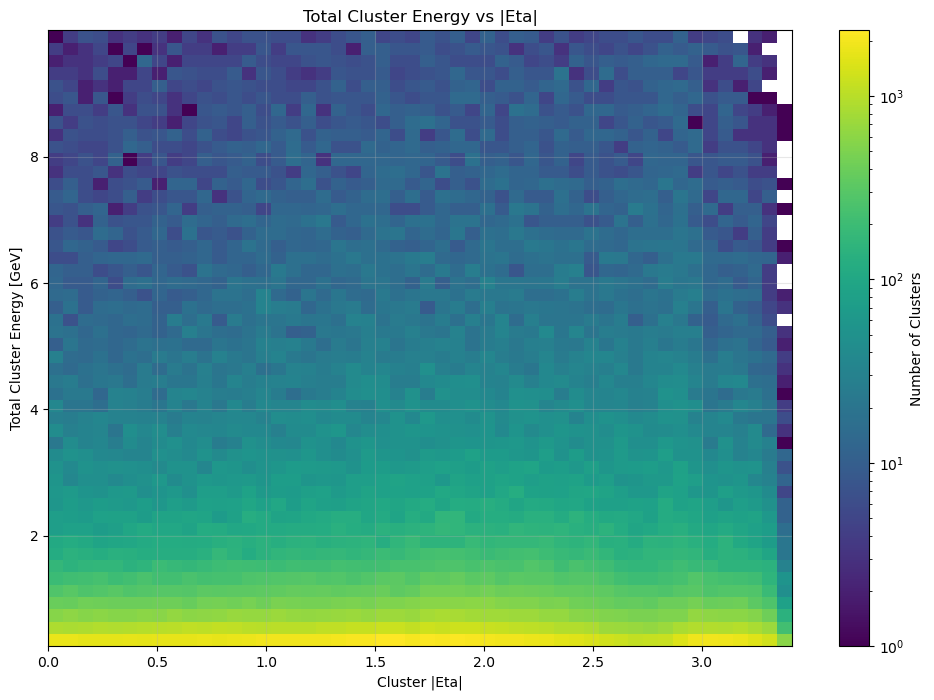

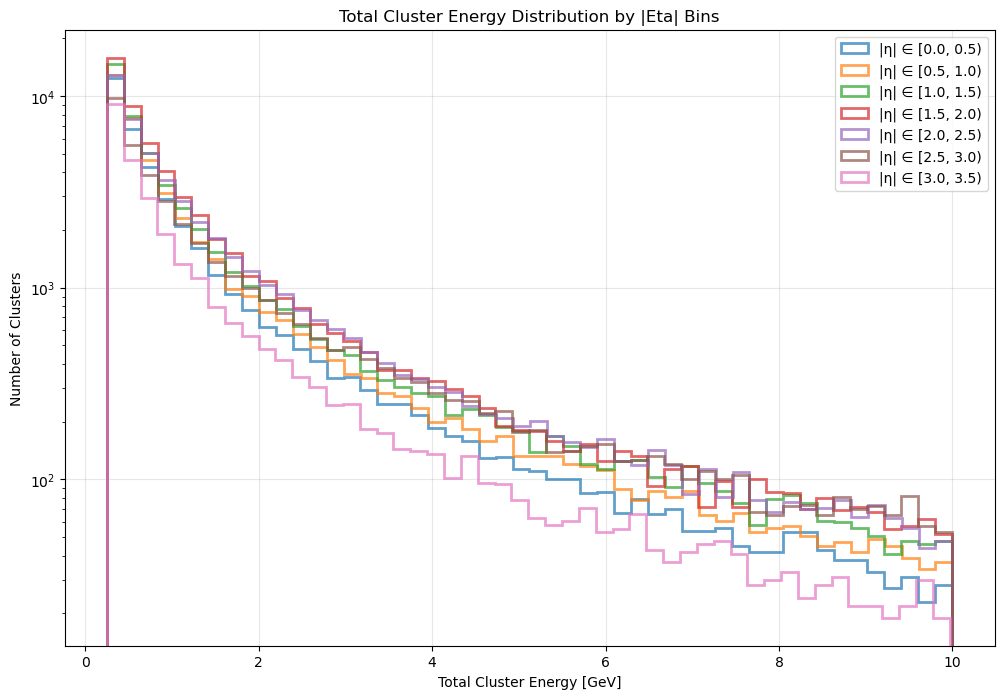

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Explode the lists to get individual cluster data
exploded_clusters = df_clusters.select([
    pl.col("event_id"),
    pl.col("cluster_id"),
    pl.col("total_cluster_energy"),
    pl.col("cluster_eta"),
    pl.col("cluster_phi")
]).explode(['cluster_id', 'total_cluster_energy', 'cluster_eta', 'cluster_phi'])

# Convert to numpy arrays for plotting
energies = exploded_clusters["total_cluster_energy"].to_numpy()
etas = exploded_clusters["cluster_eta"].to_numpy()

# Filter for reasonable energy range (0.001 to 10 GeV) and eta range (-4 to 4)
mask = (energies >= 0.001) & (energies <= 10) & (etas >= -4) & (etas <= 4)
energies_filtered = energies[mask]
etas_filtered = np.abs(etas[mask])  # Use absolute value of eta

# Create 2D histogram of energy vs |eta|
plt.figure(figsize=(12, 8))
plt.hist2d(etas_filtered, energies_filtered, bins=(50, 50), cmap='viridis', norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(label='Number of Clusters')
plt.title('Total Cluster Energy vs |Eta|')
plt.xlabel('Cluster |Eta|')
plt.ylabel('Total Cluster Energy [GeV]')
plt.grid(True, alpha=0.3)
plt.show()

# Alternative: Histogram of energy for different |eta| bins
eta_bins = np.linspace(0, 4, 9)  # 8 bins from 0 to 4 for |eta|
plt.figure(figsize=(12, 8))

for i in range(len(eta_bins)-1):
    eta_mask = (etas_filtered >= eta_bins[i]) & (etas_filtered < eta_bins[i+1])
    energies_in_bin = energies_filtered[eta_mask]
    
    if len(energies_in_bin) > 0:
        plt.hist(energies_in_bin, bins=50, alpha=0.7, 
                label=f'|η| ∈ [{eta_bins[i]:.1f}, {eta_bins[i+1]:.1f})', 
                histtype='step', linewidth=2)

plt.title('Total Cluster Energy Distribution by |Eta| Bins')
plt.xlabel('Total Cluster Energy [GeV]')
plt.ylabel('Number of Clusters')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

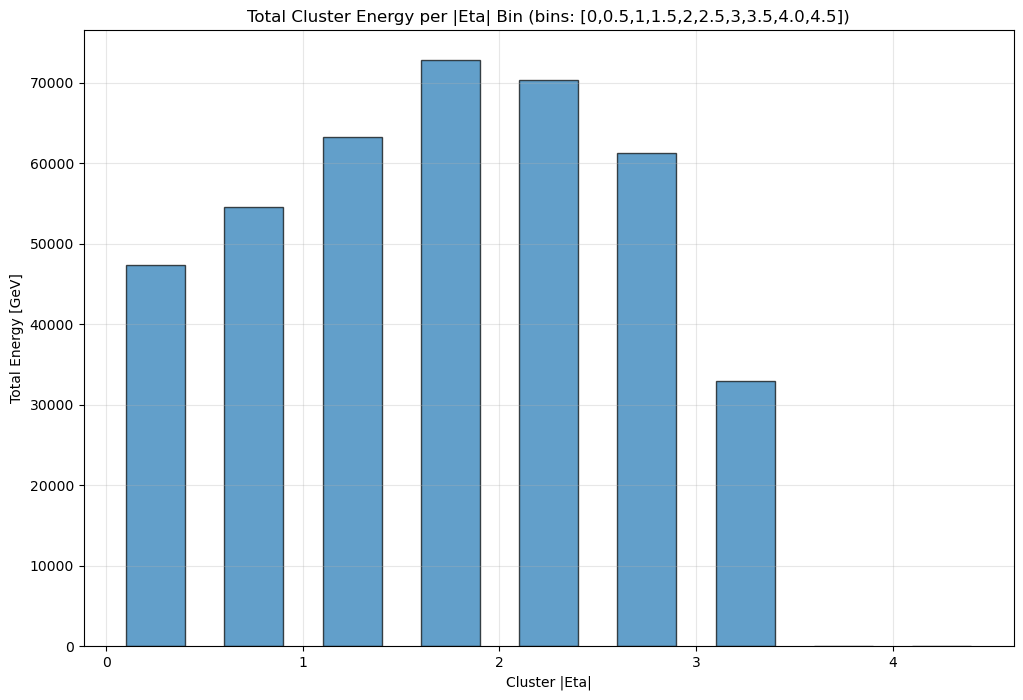

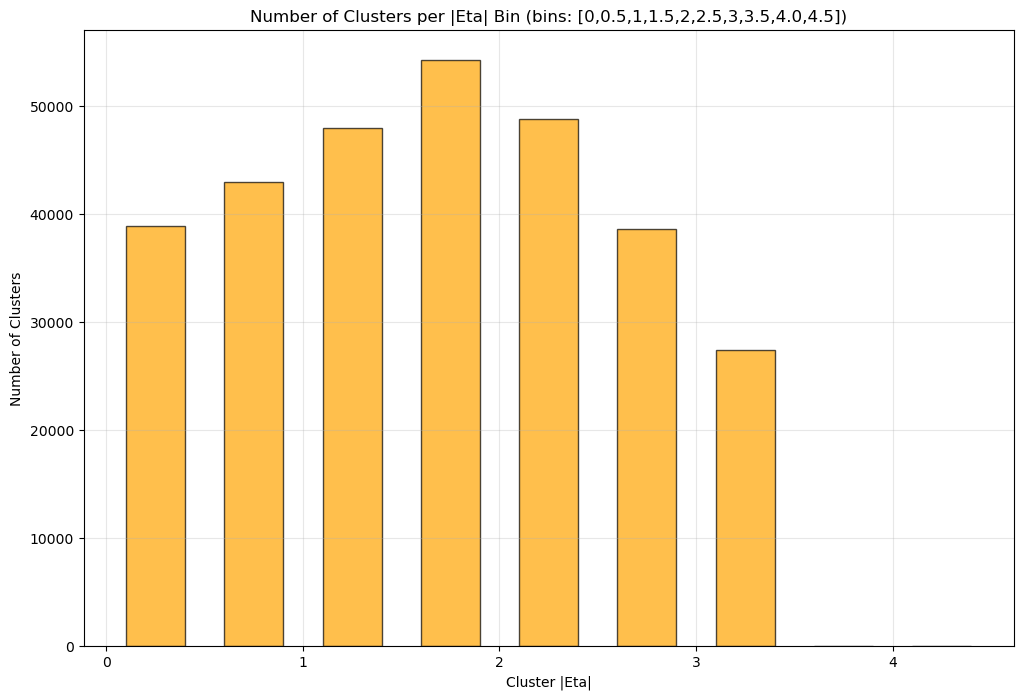

|Eta| bin statistics:
Bin 0: |η| center=0.2, total_energy=47313.24 GeV, num_clusters=38961
Bin 1: |η| center=0.8, total_energy=54614.34 GeV, num_clusters=42980
Bin 2: |η| center=1.2, total_energy=63305.42 GeV, num_clusters=48015
Bin 3: |η| center=1.8, total_energy=72882.86 GeV, num_clusters=54340
Bin 4: |η| center=2.2, total_energy=70381.97 GeV, num_clusters=48878
Bin 5: |η| center=2.8, total_energy=61278.32 GeV, num_clusters=38668
Bin 6: |η| center=3.2, total_energy=33005.76 GeV, num_clusters=27434
Bin 7: |η| center=3.8, total_energy=0.00 GeV, num_clusters=0
Bin 8: |η| center=4.2, total_energy=0.00 GeV, num_clusters=0


In [19]:
# Calculate total energy and number of clusters for each |eta| bin
eta_bins = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4.0, 4.5])  # Custom bins for |eta|
bin_centers = (eta_bins[:-1] + eta_bins[1:]) / 2
total_energies = []
num_clusters = []

for i in range(len(eta_bins)-1):
    eta_mask = (etas_filtered >= eta_bins[i]) & (etas_filtered < eta_bins[i+1])
    energies_in_bin = energies_filtered[eta_mask]
    total_energy = energies_in_bin.sum()
    num_cluster = len(energies_in_bin)
    total_energies.append(total_energy)
    num_clusters.append(num_cluster)

# Bar chart for total energy per |eta| bin
plt.figure(figsize=(12, 8))
plt.bar(bin_centers, total_energies, width=0.3, alpha=0.7, edgecolor='black')
plt.title('Total Cluster Energy per |Eta| Bin (bins: [0,0.5,1,1.5,2,2.5,3,3.5,4.0,4.5])')
plt.xlabel('Cluster |Eta|')
plt.ylabel('Total Energy [GeV]')
plt.grid(True, alpha=0.3)
plt.show()

# Bar chart for number of clusters per |eta| bin
plt.figure(figsize=(12, 8))
plt.bar(bin_centers, num_clusters, width=0.3, alpha=0.7, edgecolor='black', color='orange')
plt.title('Number of Clusters per |Eta| Bin (bins: [0,0.5,1,1.5,2,2.5,3,3.5,4.0,4.5])')
plt.xlabel('Cluster |Eta|')
plt.ylabel('Number of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

# Print the values
print("|Eta| bin statistics:")
for i, (center, energy, n_clust) in enumerate(zip(bin_centers, total_energies, num_clusters)):
    print(f"Bin {i}: |η| center={center:.1f}, total_energy={energy:.2f} GeV, num_clusters={n_clust}")

In [30]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
from primary.calibration import CALIBRATION
calo = calo_hits

cluster_stats = (
    calo.lazy()
    .select(["event_id", "cluster_id"])
    .explode("cluster_id")
    .group_by(["event_id", "cluster_id"])
    .agg(pl.count().alias("count"))
    .rename({"count": "cluster_size"})
    .collect()
)
size_cdf = (
    cluster_stats.lazy()
    .group_by("cluster_size")
    .agg(pl.count().alias("num_clusters"))
    .sort("cluster_size")
    .collect()
    .with_columns([
        pl.col("num_clusters").cum_sum().shift(1).fill_null(0).alias("clusters_lt"),
    ])
    .with_columns([
        (pl.col("clusters_lt") / pl.col("num_clusters").sum() * 100).alias("percentage_lt"),
    ])
)

fig = go.Figure(
    go.Scatter(
        x=size_cdf["cluster_size"],
        y=size_cdf["percentage_lt"],
        mode="markers+lines",
        marker=dict(size=8, color="mediumslateblue"),
        hovertemplate="Partition size < %{x}<br>Share: %{y:.2f}%<extra></extra>",
    )
)
fig.update_layout(
    title="Cumulative share of partitions by size",
    xaxis_title="Partition size (cells)",
    yaxis_title="Percentage of partitions",
    yaxis=dict(range=[0, 100]),
)
fig.show()



cluster_energy_stats = (
    calo.lazy()
    .select(["event_id", "cluster_id", "detector", "total_energy"])
    .explode(["cluster_id", "detector", "total_energy"])
    .join(
        CALIBRATION.lazy().select(["detector", "calib_factor"]),
        on="detector",
    )
    .group_by(["event_id", "cluster_id"])
    .agg([
        pl.len().alias("cluster_size"),
        (pl.col("total_energy") * pl.col("calib_factor")).sum().alias("cluster_energy"),
    ])
    .collect(streaming=True)
)

# 2. Calculate Global Energy Distribution
energy_cdf = (
    cluster_energy_stats.lazy()
    # BUG FIX: Group ONLY by cluster_size. 
    # We want to sum the energy of ALL clusters of size X in the entire dataset.
    .group_by("cluster_size")
    .agg([
        pl.col("cluster_energy").sum().alias("total_energy_at_size"),
    ])
    .sort("cluster_size")
    .with_columns([
        # Cumulative sum of the GLOBAL energy
        pl.col("total_energy_at_size")
        .cum_sum()
        .shift(1)
        .fill_null(0)
        .alias("energy_lt_global")
    ])
    .with_columns([
        # Normalize by the grand total energy of the entire dataset
        (pl.col("energy_lt_global") / pl.col("total_energy_at_size").sum() * 100)
        .alias("avg_energy_pct")
    ])
    .collect()
)

# 3. Plot
fig = go.Figure(
    go.Scatter(
        x=energy_cdf["cluster_size"],
        y=energy_cdf["avg_energy_pct"],
        mode="markers+lines",
        marker=dict(size=6, color="darkorchid"),
        line=dict(width=2),
        hovertemplate="Partition size < %{x}<br>Total Energy share: %{y:.2f}%<extra></extra>",
    )
)
fig.update_layout(
    title="Cumulative share of energy by partition size (Global)",
    xaxis_title="Partition size (cells)",
    yaxis_title="Energy share [%]",
    yaxis=dict(range=[0, 100]),
    template="plotly_white"
)
fig.show()


/tmp/ipykernel_595929/3713621785.py:12: DeprecationWarning:

`pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)

/tmp/ipykernel_595929/3713621785.py:19: DeprecationWarning:

`pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)



/tmp/ipykernel_595929/3713621785.py:62: DeprecationWarning:

the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.



In [ ]:
# 1. Calculate Cluster Count Distribution sorted by Energy
cluster_count_by_energy_cdf = (
    cluster_energy_stats.lazy()
    .group_by("cluster_energy")
    .agg([
        # Count how many clusters exist at this specific energy level
        pl.len().alias("num_clusters_at_energy")
    ])
    .sort("cluster_energy")
    .with_columns([
        # Cumulative sum of the COUNT of clusters
        pl.col("num_clusters_at_energy")
        .cum_sum()
        .shift(1)
        .fill_null(0)
        .alias("clusters_lt")
    ])
    .with_columns([
        # Normalize by the total NUMBER of clusters
        (pl.col("clusters_lt") / pl.col("num_clusters_at_energy").sum() * 100)
        .alias("cluster_count_pct")
    ])
    .collect()
)

# 2. Plot
fig = go.Figure(
    go.Scatter(
        x=cluster_count_by_energy_cdf["cluster_energy"],
        y=cluster_count_by_energy_cdf["cluster_count_pct"],
        mode="markers+lines",
        # Teal color to distinguish from energy share plots
        marker=dict(size=4, color="teal"), 
        line=dict(width=2),
        hovertemplate="Cluster Energy < %{x:.2f}<br>Percentage of Clusters: %{y:.2f}%<extra></extra>",
    )
)

fig.update_layout(
    title="Cumulative share of clusters by cluster energy",
    xaxis_title="Cluster Energy",
    yaxis_title="Percentage of Clusters [%]",
    yaxis=dict(range=[0, 100]),
    template="plotly_white",
)

# Optional: If your energy spans many orders of magnitude, uncomment below:
# fig.update_layout(xaxis_type="log")

fig.show()

In [21]:
# 0. Calculate the Global Target (Truth) Energy
# We sum the energy of ALL target particles across ALL events to get one scalar value.
total_target_energy_global = (
    particles.lazy()
    .select(['event_id', 'particle_id', 'is_target_particle', 'energy'])
    .explode(['is_target_particle', 'particle_id', 'energy'])
    .filter(pl.col('is_target_particle'))
    .select(pl.col('energy').sum())  # Sum everything into one number
    .collect()
    .item()  # Extract the float value
)

print(f"Global Target Energy (Truth): {total_target_energy_global:.2f}")

# ---------------------------------------------------------
# Plot 1: Cumulative Energy Share (Normalized by TRUTH)
# ---------------------------------------------------------

energy_by_energy_cdf = (
    cluster_energy_stats.lazy()
    .group_by("cluster_energy")
    .agg([
        pl.col("cluster_energy").sum().alias("total_energy_at_this_level")
    ])
    .sort("cluster_energy")
    .with_columns([
        # Cumulative sum of reconstructed energy
        pl.col("total_energy_at_this_level")
        .cum_sum()
        .shift(1)
        .fill_null(0)
        .alias("energy_lt_sum")
    ])
    .with_columns([
        # HERE IS THE CHANGE: Normalize by total_target_energy_global
        (pl.col("energy_lt_sum") / total_target_energy_global * 100)
        .alias("energy_share_pct")
    ])
    .collect()
)

fig1 = go.Figure(
    go.Scatter(
        x=energy_by_energy_cdf["cluster_energy"],
        y=energy_by_energy_cdf["energy_share_pct"],
        mode="markers+lines",
        marker=dict(size=4, color="crimson"),
        line=dict(width=2),
        hovertemplate="Cluster Energy < %{x:.2f}<br>Share of Truth Energy: %{y:.2f}%<extra></extra>",
    )
)

fig1.update_layout(
    title=f"Cumulative Reconstructed Energy (Normalized by Target Truth Energy)<br><sup>Global Truth Energy: {total_target_energy_global:.2e}</sup>",
    xaxis_title="Cluster Energy",
    yaxis_title="% of Total Truth Energy",
    # Y-axis might exceed 100 or be less than 100, so we let it auto-scale or set a wide range
    yaxis=dict(range=[0, max(105, energy_by_energy_cdf["energy_share_pct"].max())]),
    template="plotly_white",
)
fig1.show()

# ---------------------------------------------------------
# Plot 2: Cumulative Cluster Count (Standard Normalization)
# ---------------------------------------------------------
# Note: Changing "Total Energy" doesn't usually change the definition of 
# "Percentage of Clusters", so this is normalized by total COUNT (0-100%).

cluster_count_cdf = (
    cluster_energy_stats.lazy()
    .group_by("cluster_energy")
    .agg(pl.len().alias("count_at_level"))
    .sort("cluster_energy")
    .with_columns([
        pl.col("count_at_level").cum_sum().shift(1).fill_null(0).alias("count_lt")
    ])
    .with_columns([
        (pl.col("count_lt") / pl.col("count_at_level").sum() * 100).alias("count_pct")
    ])
    .collect()
)

fig2 = go.Figure(
    go.Scatter(
        x=cluster_count_cdf["cluster_energy"],
        y=cluster_count_cdf["count_pct"],
        mode="markers+lines",
        marker=dict(size=4, color="teal"),
        line=dict(width=2),
        hovertemplate="Cluster Energy < %{x:.2f}<br>% of Clusters: %{y:.2f}%<extra></extra>",
    )
)

fig2.update_layout(
    title="Cumulative Share of Cluster Count by Energy",
    xaxis_title="Cluster Energy",
    yaxis_title="Percentage of Clusters [%]",
    yaxis=dict(range=[0, 100]),
    template="plotly_white",
)
fig2.show()

# ---------------------------------------------------------
# Plot 3: Scatter Plot (Energy vs Size)
# ---------------------------------------------------------

fig3 = go.Figure(
    go.Scattergl(
        x=cluster_energy_stats["cluster_energy"],
        y=cluster_energy_stats["cluster_size"],
        mode="markers",
        marker=dict(
            size=3,
            color="royalblue",
            opacity=0.4
        ),
        hovertemplate="Energy: %{x:.2f}<br>Size: %{y}<extra></extra>",
    )
)

fig3.update_layout(
    title="Cluster Size vs. Cluster Energy",
    xaxis_title="Cluster Energy",
    yaxis_title="Cluster Size (cells)",
    template="plotly_white",
    # xaxis_type="log", # Uncomment for log scale
    # yaxis_type="log"
)
fig3.show()

Global Target Energy (Truth): 4258810.00


NameError: name 'cluster_energy_stats' is not defined